In [1]:
# !pip install pauliopt

In [2]:
import numpy as np
from src.envs.generators import Circuits
from src.envs.diag_t import DiagT
# from numpy import random as rng
rng = np.random.RandomState(1337)

In [3]:
qubits = 10
steps = 1000

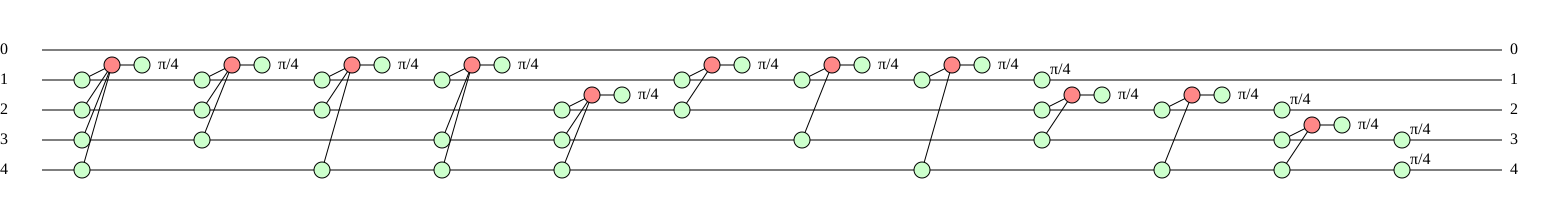

In [4]:
c = DiagT(5, ignore_cliffords=True).add_gadget(6, (1,2,3)).spider_nest((1,2,3,4))
c

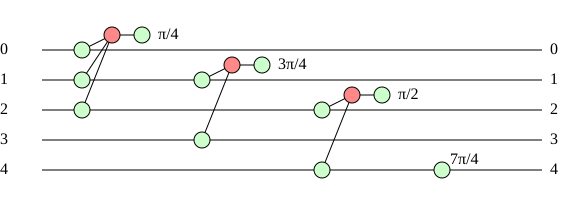

In [24]:
c = DiagT(5, ignore_cliffords=False).add_gadget(1, (0, 1, 2)).add_gadget(3, (1, 3)).add_gadget(7, (4, )).add_gadget(2, (2, 4))
c

In [25]:
from src.envs.encoders import Circuit

params.log_depth = True
params.max_int = True

Circuit(params).encode(c)

['nqubits=5',
 'q0',
 'q1',
 'q2',
 'Z(1T)',
 'q1',
 'q3',
 'Z(3T)',
 'q2',
 'q4',
 'Z(2T)',
 'q4',
 'Z(7T)']

In [20]:
from src.envs.generators import Circuits
import numpy as np

params = lambda _: None
params.log_depth = True
params.max_int = True
params.min_qubits = 6
params.max_qubits = 6
params.qubit_step = 1
params.min_depth = 50
params.max_depth = 50
params.depth_step = 1
params.walk_steps = None

c = Circuits(params).generate(np.random.RandomState())
c

(DiagT(6, {(0, 3, 4): 1, (2, 5): 1, (3, 4): 1, (0,): 1, (2, 3, 4): 1, (1, 5): 1, (0, 1, 2, 3, 5): 1, (1, 2, 3, 4, 5): 1, (0, 1, 2, 3, 4): 1, (0, 4, 5): 1, (2, 3, 5): 1, (0, 1, 2, 5): 1, (2, 4): 1, (0, 2, 5): 1, (4,): 1, (0, 5): 1, (1,): 1, (2, 3): 1, (0, 1, 2, 4): 1, (0, 2, 3, 4, 5): 1, (0, 1, 2, 3): 1, (1, 2, 4): 1}, True),
 DiagT(6, {(0, 2): 1, (1, 2, 5): 1, (0, 1, 4): 1, (0, 2, 4): 1, (1, 3, 4): 1, (1, 2): 1, (0, 1, 2): 1, (0, 1, 3, 4): 1, (2,): 1, (1, 4, 5): 1}, True),
 6,
 50)

In [26]:
from src.envs.encoders import Circuit

len(Circuit(params).encode(c[0]))

88

In [27]:
params.min_qubits = params.max_qubits = 7
d = Circuits(params).generate(np.random.RandomState())
len(Circuit(params).encode(d[0]))

142

In [28]:
params.min_qubits = params.max_qubits = 8
d = Circuits(params).generate(np.random.RandomState())
len(Circuit(params).encode(d[0]))

271

In [5]:
from src.envs.encoders import NewCircuit

params = lambda _: None
params.log_depth = True
params.max_int = True

NewCircuit(params).encode(c)

['NO',
 'YES',
 'NO',
 'NO',
 'NO',
 'Z(1T)',
 'NO',
 'YES',
 'YES',
 'NO',
 'NO',
 'Z(1T)',
 'NO',
 'YES',
 'YES',
 'YES',
 'NO',
 'Z(1T)',
 'NO',
 'YES',
 'YES',
 'YES',
 'YES',
 'Z(1T)',
 'NO',
 'YES',
 'YES',
 'NO',
 'YES',
 'Z(1T)',
 'NO',
 'YES',
 'NO',
 'YES',
 'NO',
 'Z(1T)',
 'NO',
 'YES',
 'NO',
 'YES',
 'YES',
 'Z(1T)',
 'NO',
 'YES',
 'NO',
 'NO',
 'YES',
 'Z(1T)',
 'NO',
 'NO',
 'YES',
 'NO',
 'NO',
 'Z(1T)',
 'NO',
 'NO',
 'YES',
 'YES',
 'NO',
 'Z(1T)',
 'NO',
 'NO',
 'YES',
 'YES',
 'YES',
 'Z(1T)',
 'NO',
 'NO',
 'YES',
 'NO',
 'YES',
 'Z(1T)',
 'NO',
 'NO',
 'NO',
 'YES',
 'NO',
 'Z(1T)',
 'NO',
 'NO',
 'NO',
 'YES',
 'YES',
 'Z(1T)',
 'NO',
 'NO',
 'NO',
 'NO',
 'YES',
 'Z(1T)']

In [6]:
import torch
from torch.nn import Linear, ReLU, Sequential, Module, functional as F

vocab = ["YES", "NO", "Z(1T)"] + [f'nqubits={i}' for i in range(1, 11)]
vocab_size = len(vocab)
input_dim = 10
hidden_dim = 10

def to_one_hot(tokens):
    return F.one_hot(torch.tensor([vocab.index(t) for t in tokens]), len(vocab)).float()


class Model(Module):
    def __init__(self, n_qubits):
        super(Model, self).__init__()
        self.n_qubits = n_qubits
        self.step1 = Sequential(
            Linear(vocab_size, hidden_dim),
            ReLU(),
            Linear(hidden_dim, hidden_dim),
            ReLU(),
            Linear(hidden_dim, input_dim),
        )

        # self.step2 = Sequential(


    def forward(self, x):
        x = to_one_hot(x)[1:]
        x = self.step1(x)
        x = x.view(-1, self.n_qubits, input_dim)
        x = x.mean(dim=1)

        return x




In [7]:
Model(5)(NewCircuit(params).encode(c)).shape

RuntimeError: shape '[-1, 5, 10]' is invalid for input of size 890

In [ ]:
c.is_id()

In [ ]:
c = DiagT(5, ignore_cliffords=True).spider_nest((1,2,3,4)).spider_nest((0,1,2,3))
# c.spider_nest((1,2,3,4), k=7)
c.is_id()

In [ ]:
c = DiagT(6, ignore_cliffords=True).spider_nest((1,2,3,4,0)).spider_nest((0,1,2,3)).add_gadget(2, (1, 2))
# c.spider_nest((1,2,3,4), k=7)
c.is_id()

In [ ]:
# sample = gen.generate(rng)

steps = 1000

from pauliopt import phase as pauliopt

from pandas import Series

def random_walk_track(circ, steps, rng):
    sizes = []
    qubits = circ.n_qubits
    t = pauliopt.pi / 4
    orig_circ = circ.cloned()
    for _ in range(steps):
        size = rng.randint(4, min(circ.n_qubits, 8) + 1)
        qubits = rng.choice(range(circ.n_qubits), size=size, replace=False).tolist()
        times = rng.randint(1, 8)
        circ = circ.spider_nest(qubits, k=1)
        sizes.append(circ.n_gadgets)
    return sizes

In [ ]:
import matplotlib.pyplot as plt
for qubits in range(9, 15, 3):
    c1 = DiagT(qubits, ignore_cliffords=False)
    c2 = DiagT(qubits, ignore_cliffords=True)
    
    Series(random_walk_track(c1, steps, rng)).plot(xlabel='Steps', ylabel='n gadgets', title=f'Random walk: {qubits} qubits')
    Series(random_walk_track(c2, steps, rng)).plot(xlabel='Steps', ylabel='n gadgets')
    plt.show()

In [ ]:
from itertools import combinations
from tqdm import tqdm

threshold = 200
# probability of growing
p_above = 0.01  # if above threshold
p_below = 0.3  # if below threshold
iter = 1000


def walk(n_qubits, iter):
    dict_sizes = []
    nest_sizes = []
    circ = DiagT(n_qubits, ignore_cliffords=True)
    dict_sizes.append(circ.n_gadgets)
    nest_sizes.append(len(circ.nests))
    no_match = 0
    last_move_grow = False
    for _ in tqdm(range(iter)):
        r = rng.random()
        p = p_below if circ.n_gadgets < threshold else p_above
        if r < p:
            grow(circ)
        else:
            if last_move_grow:
                v = shrink(circ)
                if not v:
                    no_match += 1
        last_move_grow = r < p
        last_move_grow = True
        dict_sizes.append(circ.n_gadgets)
        nest_sizes.append(len(circ.nests))
    print(f"{no_match=}")
    Series(dict_sizes).plot(xlabel='Steps', ylabel='n gadgets', title=f'Random walk: {n_qubits} qubits')
    Series(nest_sizes).plot(xlabel='Steps', ylabel='n gadgets', title=f'Random walk: {n_qubits} qubits')
    plt.show()
    return circ
        

def grow(circ, max_n=10):
    n = rng.randint(4, max_n + 1)
    qs = rng.choice(range(circ.n_qubits), size=n, replace=False).tolist()
    circ.spider_nest(qs)

def shrink(circ):
    for n in (4, 5):
        for qs in combinations(range(circ.n_qubits), n):
            n_gadgets = circ.n_gadgets
            circ.spider_nest(qs)
            if circ.n_gadgets < n_gadgets:
                return True
            circ.spider_nest(qs)
    return False

In [ ]:
c0 = walk(15, 1000)

In [ ]:
c1 = walk(15, 1000)

In [ ]:
from collections import Counter
Counter([len(qs) for qs in c1._dict])

In [ ]:
from math import comb
def n_bits(n):
    return n + comb(n, 2) + comb(n, 3) + 1

In [ ]:
sum([n_bits(len(x)) for x in c1.nests])

In [ ]:
sum([DiagT(15, ignore_cliffords=False).spider_nest(x).n_gadgets for x in c1.nests])

In [ ]:
comb(15, 4)

In [ ]:
circ = DiagT(15)
counter = Counter([len(qs) for qs in c0.nests])
print(counter)
for n_q, n in counter.items():
    for _ in range(n):
        qs = rng.choice(range(circ.n_qubits), size=n_q, replace=False).tolist()
        while tuple(sorted(qs)) in circ.nests:
            qs = rng.choice(range(circ.n_qubits), size=n_q, replace=False).tolist()
        circ.spider_nest(qs)
print(sum([n_bits(len(x)) for x in circ.nests]))
print(circ.n_gadgets)
print(c0.n_gadgets)
print(Counter([len(qs) for qs in circ.nests]))

In [ ]:
circ = DiagT(15)
counter = Counter({4: 117})
print(counter)
for n_q, n in counter.items():
    for _ in range(n):
        qs = rng.choice(range(circ.n_qubits), size=n_q, replace=False).tolist()
        while tuple(sorted(qs)) in circ.nests:
            qs = rng.choice(range(circ.n_qubits), size=n_q, replace=False).tolist()
        circ.spider_nest(qs)
print(sum([n_bits(len(x)) for x in circ.nests]))
print(circ.n_gadgets)
print(c0.n_gadgets)
print(Counter([len(qs) for qs in circ.nests]))

In [ ]:
circ = DiagT(15)
for nest in c0.nests:
    circ.spider_nest(nest)
print(c0.n_gadgets)
print(circ.n_gadgets)

In [ ]:
def gen(n_qubits, steps, rng):
    circ = DiagT(n_qubits)
    t = pauliopt.pi / 4
    for _ in tqdm(range(steps)):
        size = rng.randint(4, min(circ.n_qubits, 8) + 1)
        qubits = rng.choice(range(circ.n_qubits), size=size, replace=False).tolist()
        times = rng.randint(1, 8)
        circ = circ.spider_nest(qubits, k=1)
    items = list(circ._dict.items())
    np.random.shuffle(items)
    DiagT(n_qubits, dict(items[:len(items)//3]))
    DiagT(n_qubits, dict(items[len(items)//3:]))
    return circ

In [ ]:
%%timeit

gen(10, 1000, rng)

In [ ]:
# TODO move half the bits over

circ = gen(10, 1000, rng)

In [ ]:
items = list(circ._dict.items())
np.random.shuffle(items)
dict(items[:len(items)//3])
dict(items[len(items)//3:])